In [12]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import torch.nn as nn


In [13]:
# helper functions

def prepare_node_features(stocks, sectors, volatility, market_caps, pe_ratios, implied_vol, short_interest,
                           beta, operating_margin, return_on_equity, rsi_momentum, turnover, t):

    rows = []
    t = pd.to_datetime(t)
    if not stocks:
        return torch.empty((0, 2), dtype=torch.float32)
    for stock in stocks:
        # Get factors for stock at time t (or default values if missing)
        sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
        market_cap = market_caps.loc[t, stock] if t in market_caps.index and stock in market_caps.columns else 0.0
        pe_ratio = pe_ratios.loc[t, stock] if t in pe_ratios.index and stock in pe_ratios.columns else 0.0
        implied_volatility = implied_vol.loc[t, stock] if t in implied_vol.index and stock in implied_vol.columns else 0.0
        short_int = short_interest.loc[t, stock] if t in short_interest.index and stock in short_interest.columns else 0.0
        beta_val = beta.loc[t, stock] if t in beta.index and stock in beta.columns else 0.0
        op_margin = operating_margin.loc[t, stock] if t in operating_margin.index and stock in operating_margin.columns else 0.0
        roe = return_on_equity.loc[t, stock] if t in return_on_equity.index and stock in return_on_equity.columns else 0.0
        rsi = rsi_momentum.loc[t, stock] if t in rsi_momentum.index and stock in rsi_momentum.columns else 0.0
        turn = turnover.loc[t, stock] if t in turnover.index and stock in turnover.columns else 0.0

        # Get volatility at time t (or nearest available)
        if t in volatility.index and stock in volatility.columns:
            vol = volatility.loc[t, stock]
        else:
            # Get closest date
            available_dates = volatility.index[volatility.index <= t]
            if len(available_dates) > 0:
                closest_date = available_dates[-1]
                vol = volatility.loc[closest_date, stock]
            else:
                vol = 0.0  # Default if no data available
        rows.append([sector_id, vol, market_cap, pe_ratio, implied_volatility, short_int, beta_val, op_margin, roe, rsi, turn])
        # features is (N, 11)
    features = np.array(rows, dtype=np.float32)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)#


    if len(features) >0:
        num_cols = features.shape[1]
        for i in range(num_cols):  # Normalize each feature to [0, 1]
            if features[:, i].max() > features[:, i].min():
                features[:, i] = (features[:, i] - features[:, i].min()) / (features[:, i].max() - features[:, i].min() + 1e-8)

    non_zero_count = np.count_nonzero(features)
    total_elements = features.size
    zero_fraction = 1.0 - (non_zero_count / total_elements)
    
    if zero_fraction > 0.9: # If more than 90% of data is zero
        print(f"\n[WARNING] Time {t}: {zero_fraction*100:.1f}% of features are ZERO.")
        print("Sample Row (first stock):", features[0])
        # Check raw dataframe lookup for one stock to debug
        test_stock = stocks[0]
        print(f"Debug check for {test_stock} at {t}:")
        if test_stock in pe_ratios.columns:
            # Check if exact date exists
            date_exists = t in pe_ratios.index
            print(f"  - Date {t} in PE_ratios index? {date_exists}")
            if not date_exists:
                # Show nearest dates
                print(f"  - PE_ratios nearby dates: {pe_ratios.index[pe_ratios.index.get_indexer([t], method='nearest')]}")
                
    return torch.tensor(features, dtype=torch.float32)

def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]

    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    active = window.columns[ok_nonzero].tolist()

    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)
        
        active = list(active_set)

    return active


In [14]:
# basic autoencoder for anomaly detection
class Autoencoder(nn.Module):
    def __init__(self, in_dim=11, hid_dim=32, bottleneck=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hid_dim), nn.ReLU(),
            nn.Linear(hid_dim, bottleneck), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hid_dim), nn.ReLU(),
            nn.Linear(hid_dim, in_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [15]:
# load data
def load_and_fix_index(filename):
    df = pd.read_csv(filename, index_col=0)
    df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
    df = df[~df.index.duplicated(keep='last')]
    df.dropna(how='all', inplace=True)
    df = df.ffill().bfill()
    return df

# Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')
sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                        header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes
# Example placeholder setup to make this runnable in context
# Replace these lines with your actual data loading block
# ---------------------------------------------------------
returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns.dropna(how='all', inplace=True) 
returns = returns.pct_change().dropna(how='all')
returns = returns.ffill().bfill()
all_stocks = returns.columns.get_level_values(0).unique().tolist()
# ---------------------------------------------------------
train_returns = returns.loc['2012-01-01':'2019-12-31']
test_returns = returns.loc['2020-01-01':'2024-12-31']
volatility = returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
feature_dfs_list = [
    Market_caps, PE_ratios, Implied_vol, Beta, 
    Operating_margin, Return_on_equity, RSI_momentum, 
    Short_interest, Turnover, volatility
]
K = 21
# Train/Test Split
train_dates = train_returns.index # Example subset
test_dates = test_returns.index
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)
test_prices = prices.loc['2020-01-01':'2024-01-31']
train_prices = prices.loc['2012-01-01':'2019-12-31']
train_volatility = volatility.loc['2012-01-01':'2019-12-31']


C:\Users\archi\AppData\Local\Temp\ipykernel_47092\235713039.py:32: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = returns.pct_change().dropna(how='all')


In [18]:
# Collect all training features first
from sklearn.preprocessing import StandardScaler

all_features = []
for t in train_dates:
    stocks = get_active_stocks(train_returns, t, lookback_days=K, feature_dfs=feature_dfs_list)
    X = prepare_node_features(stocks, sectors, volatility, Market_caps, PE_ratios, Implied_vol, Short_interest,
                               Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover, t) # with the fix
    all_features.append(X)

all_features = np.vstack(all_features)
scaler = StandardScaler()
all_features = scaler.fit_transform(all_features)
X_train = torch.tensor(all_features, dtype=torch.float32)

# Then train properly
dataset = torch.utils.data.TensorDataset(X_train)
loader = torch.utils.data.DataLoader(dataset, batch_size=512, shuffle=True)

model = Autoencoder()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(100):
    for (batch,) in loader:
        x_hat = model(batch)
        loss = ((batch - x_hat) ** 2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [ ]:
# # training 

# dataset = torch.utils.data.TensorDataset(X_train)
# loader = torch.utils.data.DataLoader(dataset, batch_size=512, shuffle=True)

# model = Autoencoder()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# criterion = nn.MSELoss(reduction='none')  # 'none' gives per-sample loss

# print(f'starting training')
# for t in train_dates:
#     #print(f'training on date {t}')
#     stocks = get_active_stocks(train_returns, t, lookback_days=252, feature_dfs=feature_dfs_list)
#     train_features_scaled = prepare_node_features(stocks, sectors, volatility, Market_caps, PE_ratios, Implied_vol, Short_interest,
#                               Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover, t)
    
#     X_train = torch.tensor(train_features_scaled, dtype=torch.float32)

#     for epoch in range(3):
#         #print(f'  Epoch {epoch+1}/3')
#         x_hat = model(X_train)
#         loss = criterion(x_hat, X_train).mean()
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

In [19]:
# testing
test_results = {} # t: (stocks, signals)

for t in test_dates:
    #print(f'evaluating on date {t}')
    stocks = get_active_stocks(test_returns, t, lookback_days=252, feature_dfs=feature_dfs_list)
    test_features_scaled = prepare_node_features(stocks, sectors, volatility, Market_caps, PE_ratios, Implied_vol, Short_interest,
                              Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover, t)
    
    X_test = torch.tensor(test_features_scaled, dtype=torch.float32)
    with torch.no_grad():
        x_hat = model(X_test)
        scores = ((X_test - x_hat) ** 2).sum(dim=1).numpy()
    test_results[t] = (stocks, scores)

pd.to_pickle(test_results, 'basic_AE_test_results.pkl')

C:\Users\archi\AppData\Local\Temp\ipykernel_47092\3743600852.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(test_features_scaled, dtype=torch.float32)
C:\Users\archi\AppData\Local\Temp\ipykernel_47092\3743600852.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(test_features_scaled, dtype=torch.float32)
C:\Users\archi\AppData\Local\Temp\ipykernel_47092\3743600852.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(test_features_scaled, dtype=torch.float32)
C:\User

In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import torch


def evaluate_once(
        test_results,
        prices,
        forward_window,
        crash_threshold
):

    y_true = []
    y_scores = []

    sorted_dates = sorted(test_results.keys())

    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]

    for t in valid_dates:
        #print(f'working on date {t}')

        stocks, signals = test_results[t]
        #print(f'stocks: {stocks[:5]}... signals: {signals[:5]}...')

        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()

        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]
        #print(f'available stocks for evaluation: {available[:5]}...')

        if len(available) == 0:
            continue

        mask = [i for i,s in enumerate(stocks) if s in available]
        #print(f'mask: {mask}')

        signals = signals[mask]
        #print(f'signals: {signals}')

        p_t = prices.loc[t, available]
        #print(f'prices at time {t} for available stocks: {p_t[:5]}...') PROBLEM IN THIS LINE

        future_idx = prices.index.searchsorted(
            t + pd.Timedelta(days=forward_window)
        )

        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]

        p_future = prices.loc[future_date, available]

        fwd_returns = (p_future - p_t) / p_t

        crash = (fwd_returns < crash_threshold).astype(int) # 1 if crash, 0 if not
        #signals = np.where(signals == -1, 1, 0) # Convert Isolation Forest output to 1 for anomaly (crash signal), 0 for normal

        y_true.extend(crash.values)

        y_scores.extend(signals)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    auc = roc_auc_score(y_true, y_scores)

    baseline = y_true.mean()

    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()

    lift = precision / baseline if baseline > 0 else np.nan

    return auc, lift, baseline

def grid_search(
        test_results,
        prices,
        forward_windows,
        crash_thresholds
):

    rows = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            result = evaluate_once(
                test_results,
                prices,
                fw,
                ct
            )

            if result is None:
                continue

            auc, lift, baseline = result

            rows.append({

                "ForwardWindow": fw,

                "CrashThreshold": ct,

                "AUC": auc,

                "Lift": lift,

                "Baseline": baseline

            })

            print(
                f"FW={fw:3d} "
                f"CT={ct:6.2f} "
                f"AUC={auc:.3f} "
                f"Lift={lift:.2f}"
            )

    return pd.DataFrame(rows)


In [21]:
forward_windows = [5,10,22,44,66]

crash_thresholds = [-0.05,-0.10,-0.15,-0.20,-0.30]

#test_results = pd.read_pickle("outputs/test_results_test_fix3Mar.pkl")

#test_prices = pd.read_pickle("outputs/test_prices_test_fix3Mar.pkl") 

df_results = grid_search(

    test_results,

    test_prices,

    forward_windows,

    crash_thresholds

)
# for test_results_test : FW=  5 CT= -0.30 AUC=0.785 Lift=4.45 testing from 2020-2024


FW=  5 CT= -0.05 AUC=0.526 Lift=1.38
FW=  5 CT= -0.10 AUC=0.495 Lift=1.68
FW=  5 CT= -0.15 AUC=0.440 Lift=1.51
FW=  5 CT= -0.20 AUC=0.400 Lift=1.23
FW=  5 CT= -0.30 AUC=0.352 Lift=0.72
FW= 10 CT= -0.05 AUC=0.530 Lift=1.23
FW= 10 CT= -0.10 AUC=0.520 Lift=1.57
FW= 10 CT= -0.15 AUC=0.464 Lift=1.59
FW= 10 CT= -0.20 AUC=0.397 Lift=1.24
FW= 10 CT= -0.30 AUC=0.309 Lift=0.64
FW= 22 CT= -0.05 AUC=0.532 Lift=1.17
FW= 22 CT= -0.10 AUC=0.529 Lift=1.44
FW= 22 CT= -0.15 AUC=0.481 Lift=1.56
FW= 22 CT= -0.20 AUC=0.410 Lift=1.57
FW= 22 CT= -0.30 AUC=0.284 Lift=1.08
FW= 44 CT= -0.05 AUC=0.527 Lift=1.09
FW= 44 CT= -0.10 AUC=0.529 Lift=1.28
FW= 44 CT= -0.15 AUC=0.505 Lift=1.45
FW= 44 CT= -0.20 AUC=0.445 Lift=1.58
FW= 44 CT= -0.30 AUC=0.337 Lift=1.45
FW= 66 CT= -0.05 AUC=0.529 Lift=1.16
FW= 66 CT= -0.10 AUC=0.530 Lift=1.34
FW= 66 CT= -0.15 AUC=0.512 Lift=1.53
FW= 66 CT= -0.20 AUC=0.466 Lift=1.70
FW= 66 CT= -0.30 AUC=0.366 Lift=1.75



[Accuracy Evaluation] Calculating Predictive Power...
------------------------------------------------------------
PREDICTIVE ACCURACY (Forward Window: 10 days, Crash Threshold: -5.0%)
------------------------------------------------------------
1. AUC-ROC Score:      0.5306  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)
2. Info Coefficient:   0.0348   (Correlation with actual crashes)
3. Precision (Top 10%):16.05% (Of highest signals, this % actually crashed)
4. Baseline Crash Rate:13.05% (Random probability of a crash)
5. Model Lift:         1.23x    (Model is 1.2 times better than random guessing)
------------------------------------------------------------


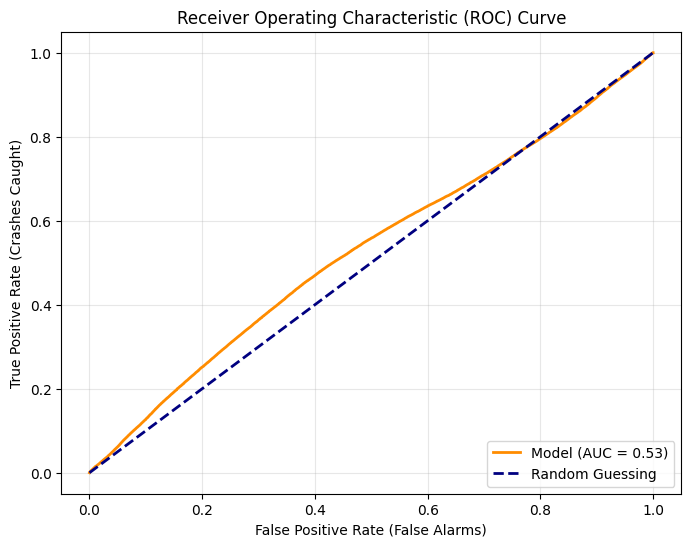


Sample Successful 'Bubble Bursts' Predicted:
      Date          Stock   Signal  Return_Next_Month
2020-01-08   BA UN Equity 1.190247          -0.054320
2020-01-09   BA UN Equity 1.209379          -0.068294
2020-01-10   BA UN Equity 1.214930          -0.050164
2020-01-24 INTC UW Equity 0.959655          -0.059150
2020-02-04 TSLA UW Equity 2.481158          -0.098111
2020-02-12   BA UN Equity 1.169896          -0.085048
2020-02-13   BA UN Equity 1.165879          -0.072691
2020-02-14   BA UN Equity 1.146520          -0.066346
2020-02-18   BA UN Equity 1.134656          -0.188179
2020-02-18   MA UN Equity 0.991643          -0.149426


In [25]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_score
import matplotlib.pyplot as plt

def evaluate_predictive_power(test_results, prices, forward_window=22, crash_threshold=-0.10):
    """
    Calculates accuracy by checking if high signals actually lead to price drops.
    
    Args:
        forward_window: Days to look ahead (e.g., 22 days = 1 month)
        crash_threshold: Return threshold to define a 'Real Crash' (e.g., -0.10 means -10% drop)
    """
    print("\n[Accuracy Evaluation] Calculating Predictive Power...")
    
    y_true = []   # 1 if stock actually crashed, 0 otherwise
    y_scores = [] # Your anomaly signal
    
    # List to track specific successful predictions for debugging
    successful_calls = []
    
    sorted_dates = sorted(list(test_results.keys()))
    
    # We stop early so we have enough data for the forward window
    valid_dates = [d for d in sorted_dates if d <= prices.index[-1] - pd.Timedelta(days=forward_window*1.5)]
    
    for t in valid_dates:
        stocks, signals = test_results[t]
        
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        signals = signals.flatten()
        
        # Calculate Forward Returns for these stocks
        # Get price at t
        p_t = prices.loc[t, stocks]
        
        # Get price at t + window
        # Find nearest valid date in future
        future_idx = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(prices): continue
        future_date = prices.index[future_idx]
        p_future = prices.loc[future_date, stocks]
        
        # Return calculation
        fwd_returns = (p_future - p_t) / p_t
        
        # Define Ground Truth: Did it crash?
        # If return < -10%, it is a "True Anomaly" (Class 1)
        is_crash = (fwd_returns < crash_threshold).astype(int)
        #signals = np.where(signals == -1, 1, 0) # Convert Isolation Forest output to 1 for anomaly (crash signal), 0 for normal
        
        y_true.extend(is_crash.values)
        y_scores.extend(signals)
        
        # Track Top Predictions
        # Combine into dataframe
        df_eval = pd.DataFrame({'Stock': stocks, 'Signal': signals, 'Return': fwd_returns, 'Crash': is_crash})
        top_picks = df_eval.sort_values('Signal', ascending=False).head(5)
        
        for _, row in top_picks.iterrows():
            if row['Crash'] == 1:
                successful_calls.append({
                    'Date': t.strftime('%Y-%m-%d'),
                    'Stock': row['Stock'],
                    'Signal': row['Signal'],
                    'Return_Next_Month': row['Return']
                })

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # --- METRIC 1: AUC-ROC ---
    # Can the model distinguish between a crash and normal price action?
    auc = roc_auc_score(y_true, y_scores)
    
    # --- METRIC 2: Information Coefficient (IC) ---
    # Correlation between Signal and Crash Probability
    # Ideally Positive (Higher Signal = Higher Probability of Crash)
    ic = np.corrcoef(y_scores, y_true)[0, 1]
    
    # --- METRIC 3: Precision @ Top 10% ---
    # If we take the top 10% highest signals, what % were actually crashes?
    threshold_top_10 = np.percentile(y_scores, 90)
    high_signal_indices = y_scores > threshold_top_10
    
    precision_top_10 = np.mean(y_true[high_signal_indices]) # % of high signals that were crashes
    baseline_crash_rate = np.mean(y_true) # % of ALL stocks that crashed
    
    # Lift: How much better is the model than random chance?
    lift = precision_top_10 / baseline_crash_rate if baseline_crash_rate > 0 else 0
    
    print("-" * 60)
    print(f"PREDICTIVE ACCURACY (Forward Window: {forward_window} days, Crash Threshold: {crash_threshold*100}%)")
    print("-" * 60)
    print(f"1. AUC-ROC Score:      {auc:.4f}  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)")
    print(f"2. Info Coefficient:   {ic:.4f}   (Correlation with actual crashes)")
    print(f"3. Precision (Top 10%):{precision_top_10:.2%} (Of highest signals, this % actually crashed)")
    print(f"4. Baseline Crash Rate:{baseline_crash_rate:.2%} (Random probability of a crash)")
    print(f"5. Model Lift:         {lift:.2f}x    (Model is {lift:.1f} times better than random guessing)")
    print("-" * 60)
    
    # --- Visualization: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.2f})", color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
    plt.xlabel('False Positive Rate (False Alarms)')
    plt.ylabel('True Positive Rate (Crashes Caught)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print("\nSample Successful 'Bubble Bursts' Predicted:")
    print(pd.DataFrame(successful_calls).head(10).to_string(index=False))

# ==============================================================================
# EXECUTION
# ==============================================================================

    # Evaluate 1-Month Forward Accuracy looking for -15% Drops
evaluate_predictive_power(test_results, test_prices, forward_window=10, crash_threshold=-0.05)
